In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CatBoost

In [3]:
# import geopandas as gpd

# blocks = gpd.read_file("../data/blocks_clean.geojson")
# blocks.head()

In [4]:
blocks = gpd.read_parquet('../data/traning_data/blocks_with_land_value_class.parquet')
blocks["land_use"] = blocks["land_use"].replace(
    [None, "None", "none", "NaN", "nan", "NULL", "null", ""],
    pd.NA
)
blocks = blocks[blocks["land_use"].notna()].copy()


blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


In [6]:
blocks_with_large_errors = gpd.read_file("../data/traning_data/blocks_with_large_errors.geojson")
blocks_with_error_over_60pct = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct.geojson")
blocks_with_error_over_60pct2 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct2.geojson")
blocks_with_error_over_60pct3 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct3.geojson")
blocks_with_error_over_60pct3.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.108342,0.000000,0.891658,0.0,0.000000,0.0,0.0,RECREATION,0.891658,0.000000,...,5,14,60,205,447,5.678058e+07,5.678058e+07,1.786907e+07,217.758932,"POLYGON ((351428.245 6647300.266, 351440.055 6..."
1,0.024715,0.072627,0.489266,0.0,0.413393,0.0,0.0,RECREATION,0.489266,161.467098,...,10,21,74,248,427,6.659308e+06,6.659308e+06,2.074318e+07,67.896405,"POLYGON ((348997.996 6646368.274, 348999.869 6..."
2,0.226151,0.590566,0.132126,0.0,0.051156,0.0,0.0,BUSINESS,0.590566,32311.556107,...,4,10,43,181,434,5.592216e+08,5.592216e+08,3.421804e+08,63.428892,"POLYGON ((351482.192 6648261.957, 351499.765 6..."
3,0.999419,0.000581,0.000000,0.0,0.000000,0.0,0.0,RESIDENTIAL,0.999419,8227.586617,...,3,9,33,82,185,2.868954e+08,2.868954e+08,1.712276e+08,67.552047,"POLYGON ((347126.83 6643214.39, 347135.632 664..."
4,0.763586,0.000000,0.000000,0.0,0.236414,0.0,0.0,RESIDENTIAL,0.763586,4099.369141,...,4,15,52,154,291,1.421954e+08,1.421954e+08,8.546343e+07,66.381611,"POLYGON ((353573.678 6646818.066, 353573.235 6..."


In [44]:
# старт
blocks_clean = blocks.copy()

# 1) удалить blocks_with_large_errors
tmp = blocks_with_large_errors
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# 2) удалить blocks_with_error_over_60pct
tmp = blocks_with_error_over_60pct
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # # 3) удалить blocks_with_error_over_60pct2
# tmp = blocks_with_error_over_60pct2
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # 4) удалить blocks_with_error_over_60pct3
# tmp = blocks_with_error_over_60pct3
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

blocks_clean.head()



,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


In [6]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(15, 15))

# # Все кварталы серым фоном
# blocks.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)

# # Отфильтрованные поверх с раскраской по land_value_per_sqm
# blocks_clean.plot(
#     ax=ax,
#     column="land_value",
#     cmap="viridis",
#     legend=True,
#     edgecolor="black",
#     linewidth=0.2
# )

# ax.axis("off")
# plt.show()

In [36]:
import pandas as pd

col = "land_use"

# Кол-во по land_use в blocks
cnt_blocks = (
    blocks[col]
    .value_counts(dropna=False)
    .rename("count_blocks")
)

# Кол-во по land_use в blocks_clean
cnt_blocks_clean = (
    blocks_clean[col]
    .value_counts(dropna=False)
    .rename("count_blocks_clean")
)

# Объединяем в одну таблицу
land_use_counts = (
    pd.concat([cnt_blocks, cnt_blocks_clean], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": col})
    .sort_values(col, na_position="last")
)

display(land_use_counts)


,land_use,count_blocks,count_blocks_clean
5,AGRICULTURE,142,129
4,BUSINESS,309,298
3,INDUSTRIAL,501,478
1,RECREATION,1671,1301
0,RESIDENTIAL,4919,4594
6,SPECIAL,126,109
2,TRANSPORT,1049,920


In [8]:
# import osmnx as ox
# import geopandas as gpd

# # 1) Граница Санкт-Петербурга
# city = ox.geocode_to_gdf("Saint Petersburg, Russia")
# city_polygon = city.geometry.iloc[0]

# # 2) Загружаем административные границы уровня 5
# tags = {
#     "boundary": "administrative",
#     "admin_level": "5",
# }

# districts = ox.features_from_polygon(city_polygon, tags=tags).reset_index()

# # 3) Оставляем только полигональные геометрии
# districts = districts[districts.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# # 4) Полезные поля
# keep_cols = [
#     c for c in [
#         "name",
#         "name:ru",
#         "official_name",
#         "boundary",
#         "admin_level",
#         "wikidata",
#         "geometry",
#     ]
#     if c in districts.columns
# ]

# districts = districts[keep_cols].drop_duplicates().reset_index(drop=True)


# districts = districts[districts["admin_level"] == "5"].copy()
# districts = districts.iloc[:-1].copy()

# districts 



In [9]:
# districts.to_file("../data/traning_data/districts_spb.geojson", driver="GeoJSON")

In [9]:
districts = gpd.read_file('../data/traning_data/districts_spb.geojson')
districts

,name,name:ru,official_name,boundary,admin_level,wikidata,geometry
0,Колпинский район,Колпинский район,None,administrative,5,Q1326302,"POLYGON ((30.44112 59.82937, 30.44333 59.8298,..."
1,Пушкинский район,Пушкинский район,None,administrative,5,Q220316,"POLYGON ((30.21822 59.67307, 30.21918 59.67361..."
2,Московский район,Московский район,None,administrative,5,Q270112,"POLYGON ((30.19877 59.80161, 30.19901 59.8018,..."
3,Красносельский район,Красносельский район,None,administrative,5,Q270124,"MULTIPOLYGON (((30.06517 59.67798, 30.07283 59..."
4,Петродворцовый район,Петродворцовый район,None,administrative,5,Q270114,"MULTIPOLYGON (((30.04464 59.8635, 30.04455 59...."
5,Невский район,Невский район,None,administrative,5,Q1193156,"POLYGON ((30.36331 59.91387, 30.36951 59.91412..."
6,Фрунзенский район,Фрунзенский район,None,administrative,5,Q1142777,"POLYGON ((30.33258 59.91305, 30.33352 59.91337..."
7,Адмиралтейский район,Адмиралтейский район,None,administrative,5,Q219746,"POLYGON ((30.25023 59.90129, 30.25028 59.90132..."
8,Василеостровский район,Василеостровский район,None,administrative,5,Q220622,"POLYGON ((30.18468 59.95472, 30.18473 59.95481..."
9,Выборгский район,Выборгский район,None,administrative,5,Q219907,"POLYGON ((30.0729 60.09727, 30.08512 60.10426,..."


In [37]:
import geopandas as gpd

# districts — GeoDataFrame с полигонами районов из OSM
# blocks_clean — GeoDataFrame с кварталами

# 1) Выбираем колонку с названием района
district_name_col = "name:ru" if "name:ru" in districts.columns else "name"

districts_for_join = districts[[district_name_col, "geometry"]].copy()
districts_for_join = districts_for_join.rename(columns={district_name_col: "district_name"})

# 2) Приводим CRS
districts_for_join = districts_for_join.to_crs(blocks_clean.crs)

# 3) Для кварталов берём внутреннюю точку, чтобы не было дублей на границах
blocks_points = blocks_clean.copy()
blocks_points["geometry"] = blocks_points.geometry.representative_point()

# 4) Spatial join
joined = gpd.sjoin(
    blocks_points[["geometry"]],
    districts_for_join,
    how="left",
    predicate="within",
)

# 5) Добавляем атрибут района обратно в blocks_clean
blocks_clean = blocks_clean.copy()
blocks_clean["district_name"] = joined["district_name"]

# 6) Проверка
display(blocks_clean[["district_name", "geometry"]].head())
print("Missing district_name:", blocks_clean["district_name"].isna().sum())


,district_name,geometry
0,Московский район,"POLYGON ((352083.617 6633950.146, 352240.448 6..."
1,Пушкинский район,"POLYGON ((346700.642 6618453.176, 346681.107 6..."
2,Пушкинский район,"POLYGON ((347043.363 6618261.219, 347042.608 6..."
3,Пушкинский район,"POLYGON ((354879.039 6618859.116, 354845.405 6..."
4,Василеостровский район,"POLYGON ((347215.933 6646341.789, 347245.429 6..."


Missing district_name: 1


In [ ]:
# districts = [
#     "Московский район",
#     "Калининский район",
#     "Василеостровский район",
#     "Петроградский район",
#     "Центральный район",
#     'Фрунзенский район',
# ]

# blocks_clean = blocks_clean[
#     blocks_clean["district_name"].isin(districts)
# ].copy()


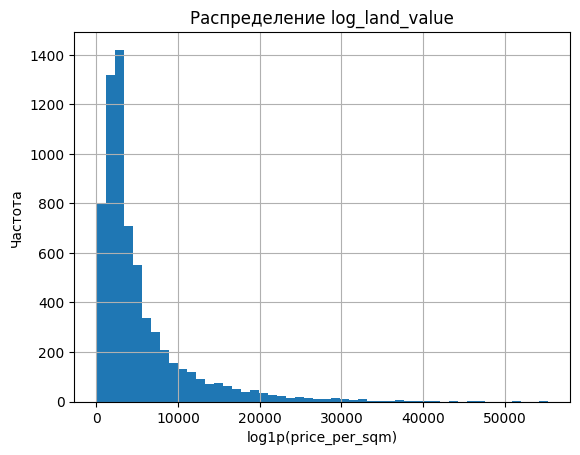

In [31]:

# Гистограмма
plt.figure()
blocks_clean['land_value_per_sqm'].hist(bins=50)
plt.xlabel('log1p(price_per_sqm)')
plt.ylabel('Частота')
plt.title('Распределение log_land_value')
plt.show()

land_value_per_sqm                1.000000
log_land_value_per_sqm            0.799650
fsi                               0.655616
gsi                               0.573225
l                                 0.468639
log_land_value                    0.442793
share_living                      0.384965
share_non_living                  0.383896
land_value_class_soft_expected    0.346178
land_value                        0.346150
land_value_class_pred             0.341171
land_value_class_soft_3           0.327030
residential                       0.326954
living_area                       0.261857
build_floor_area                  0.255544
population                        0.209842
mxi                               0.204083
non_living_area                   0.197408
footprint_area                    0.123790
land_value_class_soft_2           0.034787
business                         -0.000981
share                            -0.037905
osr                              -0.042864
special    

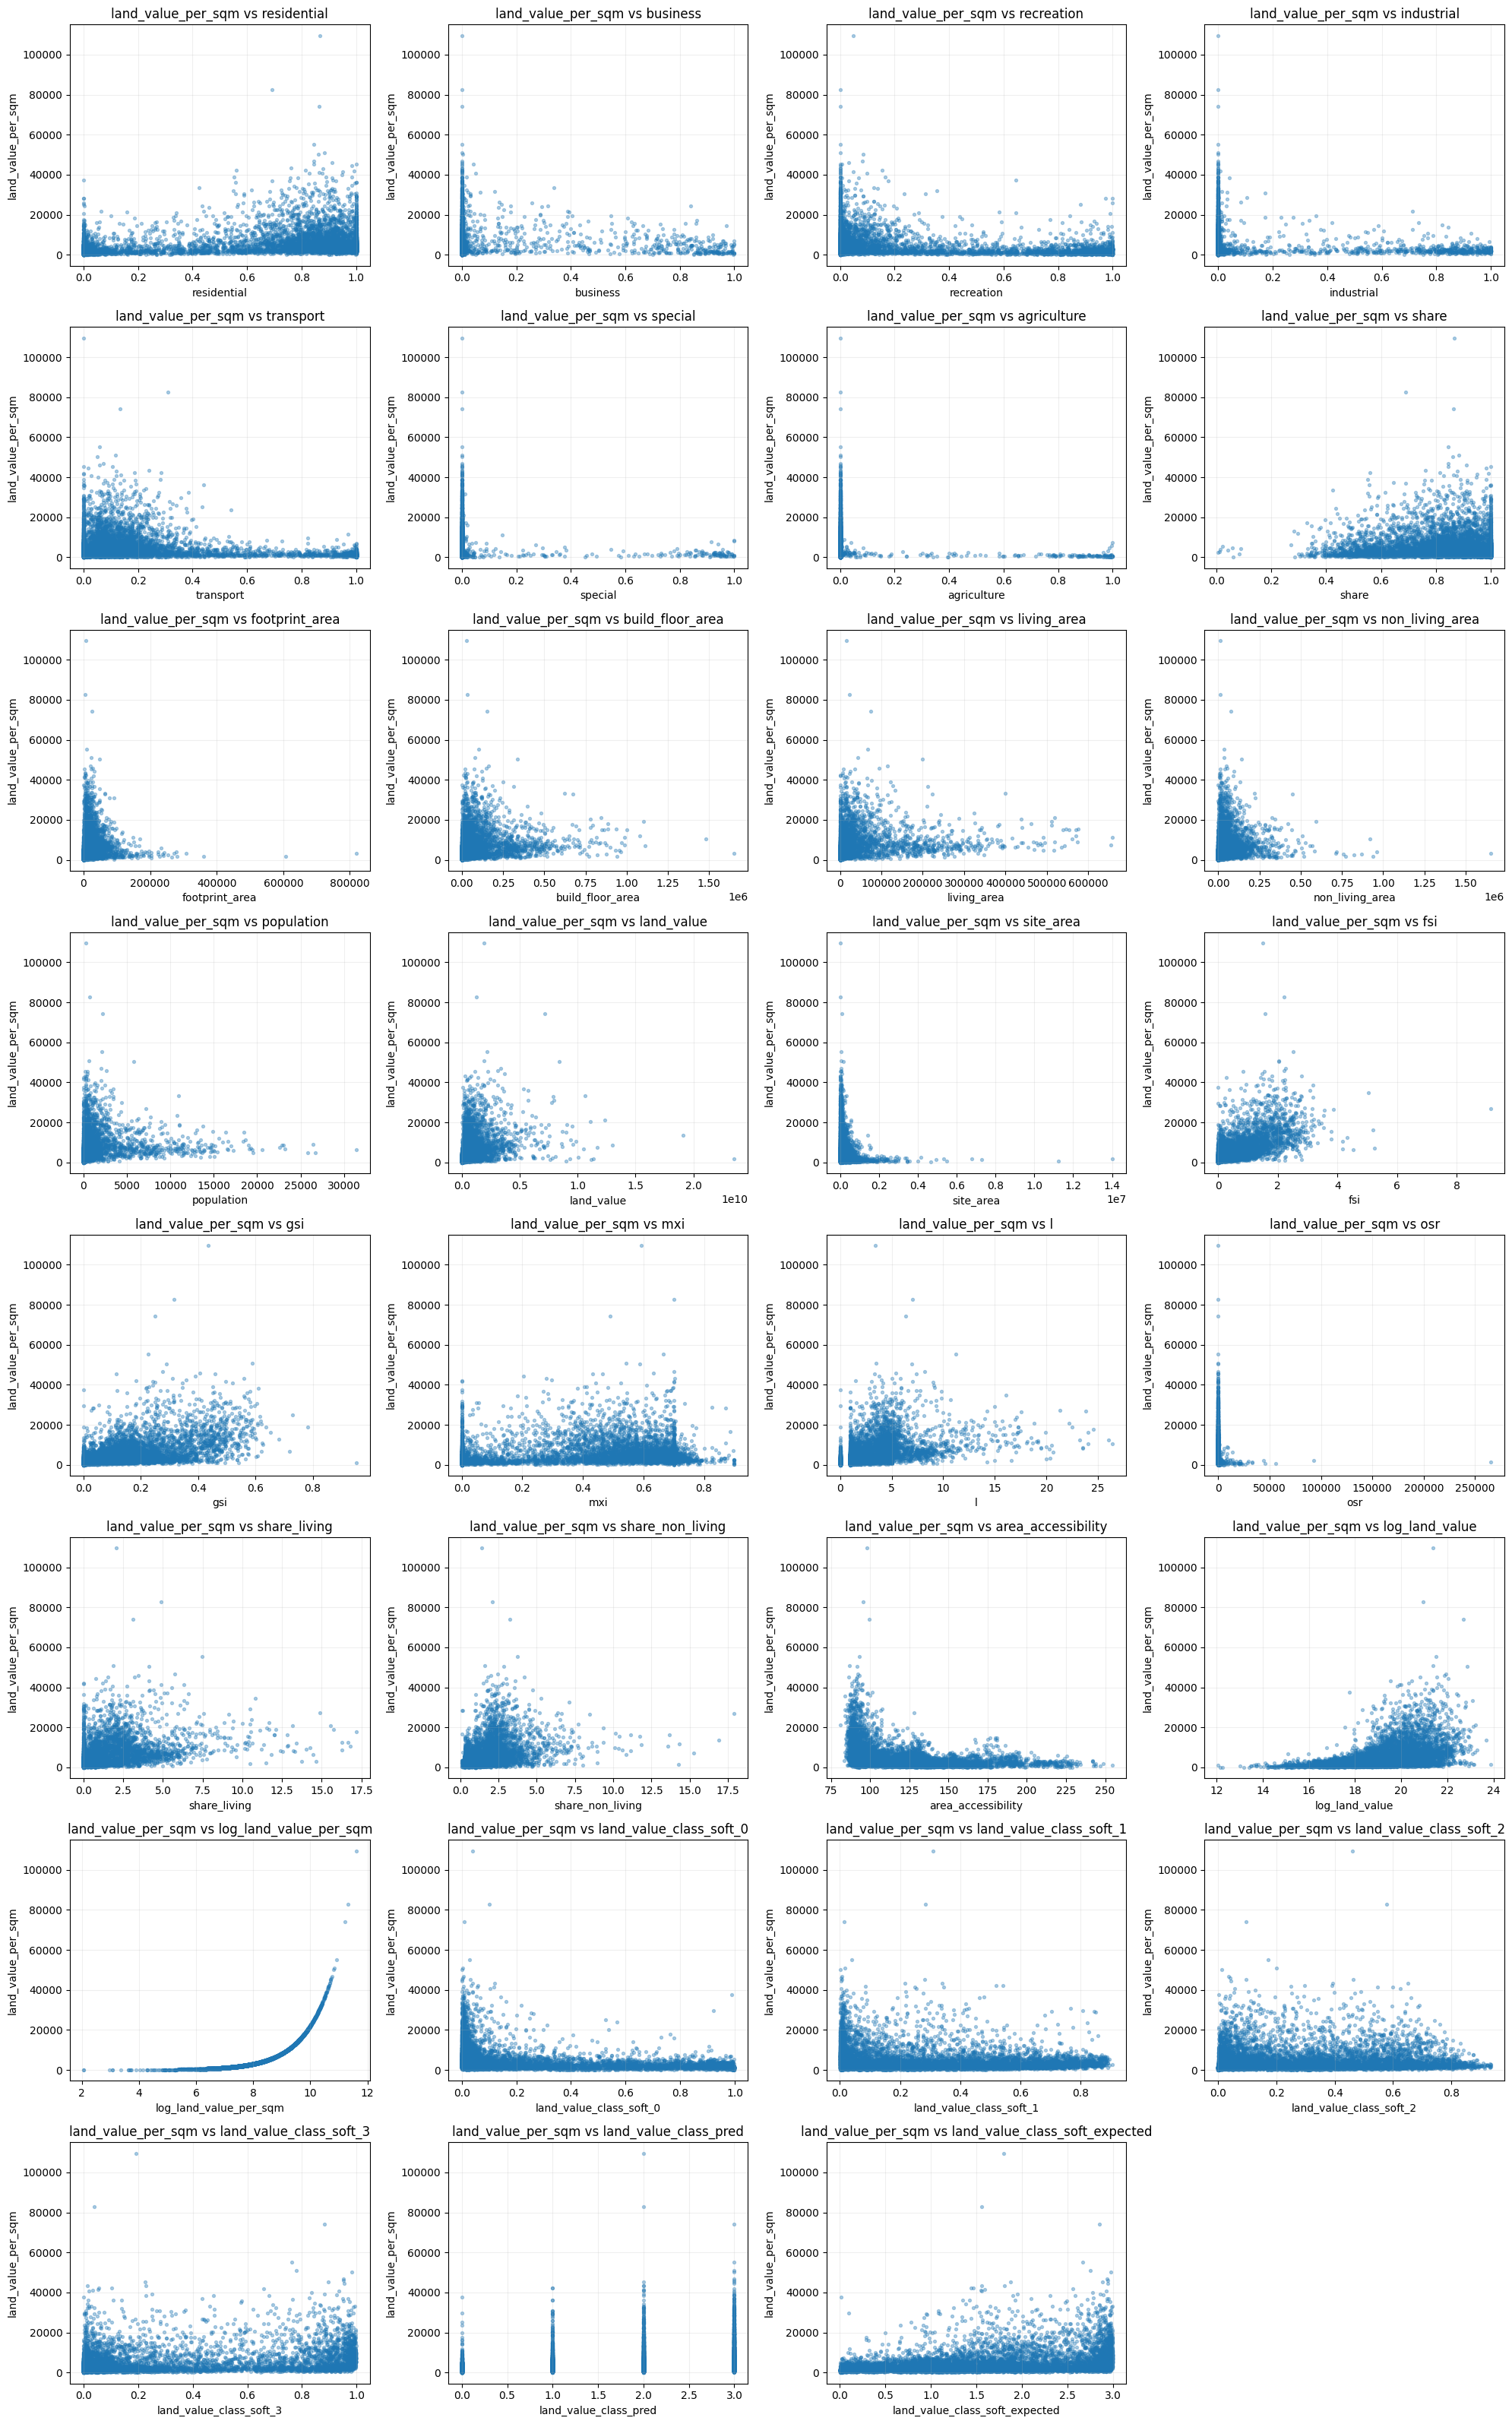

In [38]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

target_col = "land_value_per_sqm"
num_cols = [c for c in blocks_clean.columns if pd.api.types.is_numeric_dtype(blocks_clean[c])]
corr_to_target = (
    blocks_clean[num_cols]
    .corr(method="pearson")[target_col]
    .dropna()
    .sort_values(ascending=False)
)
display(corr_to_target)

# Целевая переменная
target_col = "land_value_per_sqm"

# Берем все фичи кроме target и geometry
exclude = {target_col, "geometry"}
feature_cols = [c for c in blocks_clean.columns if c not in exclude]

# Числовые фичи для scatter
num_features = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(blocks_clean[c])
]

# Подготовка
n = len(num_features)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(num_features):
    tmp = blocks_clean[[col, target_col]].dropna()
    axes[i].scatter(tmp[col], tmp[target_col], s=8, alpha=0.35)
    axes[i].set_title(f"{target_col} vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].grid(alpha=0.2)

# Удаляем пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [39]:
q = blocks_clean["land_value_per_sqm"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["land_value_per_sqm"] < q].copy()
q = blocks_clean["footprint_area"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["footprint_area"] < q].copy()
q = blocks_clean["land_value"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["land_value"] < q].copy()
q = blocks_clean["osr"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["osr"] < q].copy()
q = blocks_clean["fsi"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["fsi"] < q].copy()
q = blocks_clean["site_area"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["site_area"] < q].copy()
q = blocks_clean["living_area"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["living_area"] < q].copy()
q = blocks_clean["non_living_area"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["non_living_area"] < q].copy()
q = blocks_clean["share_living"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["share_living"] < q].copy()
q = blocks_clean["share_non_living"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["share_non_living"] < q].copy()
q = blocks_clean["population"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["population"] < q].copy()

In [22]:
q = blocks_clean["land_value_per_sqm"].quantile(0.01)
blocks_clean = blocks_clean[blocks_clean["land_value_per_sqm"] > q].copy()


In [ ]:
# === Simple train/test training with XGBoost (без фолдов) ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "log_land_value_per_sqm"
radius_list = [300, 500, 1000, 2000, 3000]
test_size = 0.2
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    "land_value_class_soft_expected",
    "district_name",
}

cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи на всем датасете
data_df = blocks_clean.copy()

for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [
    c for c in feature_cols
    if c not in cat_features and c != target_col and c in data_df.columns
]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(
    [c for c in feature_cols if c in data_lag.columns] + cat_features
))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# 4) Train/test split
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

# 5) Подготовка X / y
X_train = df_train[feats].copy()
X_test = df_test[feats].copy()

# one-hot encoding для категориальных признаков
cat_feats_for_ohe = [c for c in cat_features if c in X_train.columns]

X_train = pd.get_dummies(X_train, columns=cat_feats_for_ohe, dummy_na=False)
X_test = pd.get_dummies(X_test, columns=cat_feats_for_ohe, dummy_na=False)

# выравниваем набор колонок между train и test
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = df_train[target_col].to_numpy()
y_test = df_test[target_col].to_numpy()

# 6) Обучение
model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_estimators=40000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=seed,
    n_jobs=-1,
    early_stopping_rounds=1000,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=200,
)

# 7) Метрики на train и test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model.predict(X_train)).reshape(-1)
y_train_true_raw = y_train

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model.predict(X_test)).reshape(-1)
y_test_true_raw = y_test

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")


[0]	validation_0-rmse:0.80830
[200]	validation_0-rmse:0.34792
[400]	validation_0-rmse:0.33884
[600]	validation_0-rmse:0.33705
[800]	validation_0-rmse:0.33586
[1000]	validation_0-rmse:0.33512
[1200]	validation_0-rmse:0.33517
[1400]	validation_0-rmse:0.33523
[1600]	validation_0-rmse:0.33532
[1800]	validation_0-rmse:0.33541
[2000]	validation_0-rmse:0.33539
[2006]	validation_0-rmse:0.33538
Train metrics:
MAPE: 0.042588 (4.26%)
WAPE: 0.044164 (4.42%)
MAE:  226.383509
RMSE: 407.055833
R2:   0.993123

Test metrics:
MAPE: 0.255329 (25.53%)
WAPE: 0.239408 (23.94%)
MAE:  1182.167438
RMSE: 2108.855501
R2:   0.795421


In [40]:
# === Simple train/test training (без фолдов) ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import r2_score
import numpy as np
from catboost import CatBoostRegressor, Pool
from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "log_land_value_per_sqm"   # как в твоем ноутбуке
radius_list = [300, 500, 1000, 2000, 3000]
test_size = 0.2
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    # 'land_value_class_soft_0',
    # 'land_value_class_soft_1',
    # 'land_value_class_soft_2',
    # 'land_value_class_soft_3',
    # 'land_value_class_soft_4',
    # 'land_value_class_pred',
    "land_value_class_soft_expected",
    'district_name',
    'number_of_floors',
}
cat_features = [c for c in ["land_use", "morphotype", 'land_value_class_pred'] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи на всем датасете
data_df = blocks_clean.copy()


for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [c for c in feature_cols if c not in cat_features and c != target_col and c in data_df.columns]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys([c for c in feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# 4) Один train/test split (без кросс-валидации)
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features, feature_names=feats)

# 5) Обучение
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=20000,
    learning_rate=0.03,
    depth=6,
    subsample=0.8,
    rsm=0.8,
    od_type="Iter",
    od_wait=2000,
    random_seed=seed,
    verbose=200,
)


model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=600,
    use_best_model=True,
)

# 6) Метрики на train и test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model.predict(df_train[feats])).reshape(-1)
y_train_true_raw = df_train[target_col].to_numpy()

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")

0:	learn: 0.8918267	test: 0.9032296	best: 0.9032296 (0)	total: 4.68ms	remaining: 1m 33s
200:	learn: 0.4415118	test: 0.4699014	best: 0.4699014 (200)	total: 937ms	remaining: 1m 32s
400:	learn: 0.3808146	test: 0.4442975	best: 0.4442823 (399)	total: 1.95s	remaining: 1m 35s
600:	learn: 0.3360045	test: 0.4336024	best: 0.4336024 (600)	total: 3s	remaining: 1m 36s
800:	learn: 0.3038279	test: 0.4292064	best: 0.4291516 (794)	total: 4.01s	remaining: 1m 36s
1000:	learn: 0.2762133	test: 0.4258839	best: 0.4258666 (995)	total: 5.04s	remaining: 1m 35s
1200:	learn: 0.2533709	test: 0.4236130	best: 0.4235457 (1194)	total: 6.11s	remaining: 1m 35s
1400:	learn: 0.2321970	test: 0.4221995	best: 0.4221995 (1400)	total: 7.18s	remaining: 1m 35s
1600:	learn: 0.2147356	test: 0.4213335	best: 0.4213335 (1600)	total: 8.25s	remaining: 1m 34s
1800:	learn: 0.1987333	test: 0.4206684	best: 0.4206293 (1799)	total: 9.31s	remaining: 1m 34s
2000:	learn: 0.1847954	test: 0.4201164	best: 0.4200931 (1996)	total: 10.4s	remaining: 1

In [41]:
# === Предсказание на всем blocks_clean + таблица ошибок ===
import numpy as np
import pandas as pd

# 1) Предсказание на всех строках (используем уже подготовленный data_lag и feats)
df_all = data_lag.loc[blocks_clean.index].copy()

y_pred_raw = np.asarray(model.predict(df_all[feats])).reshape(-1)
y_true_raw = df_all[target_col].to_numpy()

# Перевод в оригинальную шкалу (например, из log -> обычная стоимость)
y_true = to_original_scale(y_true_raw, target_col=target_col)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

# 2) Процент ошибки по каждой записи
eps = 1e-12
error_pct = np.where(
    np.abs(y_true) > eps,
    np.abs(y_pred - y_true) / np.abs(y_true) * 100.0,
    np.nan
)

# 3) Итоговый датафрейм
value_col_name = (
    "land_value_per_sqm" if target_col == "log_land_value_per_sqm"
    else "land_value" if target_col == "log_land_value"
    else "target_value"
)

result_df = blocks_clean.copy()
result_df[f"current_{value_col_name}"] = y_true
result_df[f"pred_{value_col_name}"] = y_pred
result_df["error_pct"] = error_pct
result_df["abs_error"] = np.abs(y_pred - y_true)

# 4) Суммарный процент ошибки
# MAPE = средний % ошибки
total_mape_pct = np.nanmean(error_pct)

# WAPE = суммарная абсолютная ошибка / суммарное фактическое значение
total_wape_pct = (np.nansum(np.abs(y_pred - y_true)) / np.nansum(np.abs(y_true))) * 100.0

print(f"Суммарная ошибка (MAPE): {total_mape_pct:.2f}%")
print(f"Суммарная ошибка (WAPE): {total_wape_pct:.2f}%")

result_sorted = result_df.sort_values("error_pct", ascending=True)
display(result_sorted[[f"current_{value_col_name}", f"pred_{value_col_name}", "error_pct"]].head(20))


Суммарная ошибка (MAPE): 15.56%
Суммарная ошибка (WAPE): 14.41%


,current_land_value_per_sqm,pred_land_value_per_sqm,error_pct
7997,4366.956372,4366.990225,0.000775
3432,4383.251194,4383.047955,0.004637
187,2108.591329,2108.767584,0.008359
6544,1137.495485,1137.662649,0.014696
2255,2599.292488,2598.863590,0.016501
4700,2157.561281,2157.974986,0.019175
3805,7171.343882,7169.849575,0.020837
6286,849.281265,849.073498,0.024464
945,4836.790665,4838.006581,0.025139
3717,3118.277294,3119.218740,0.030191


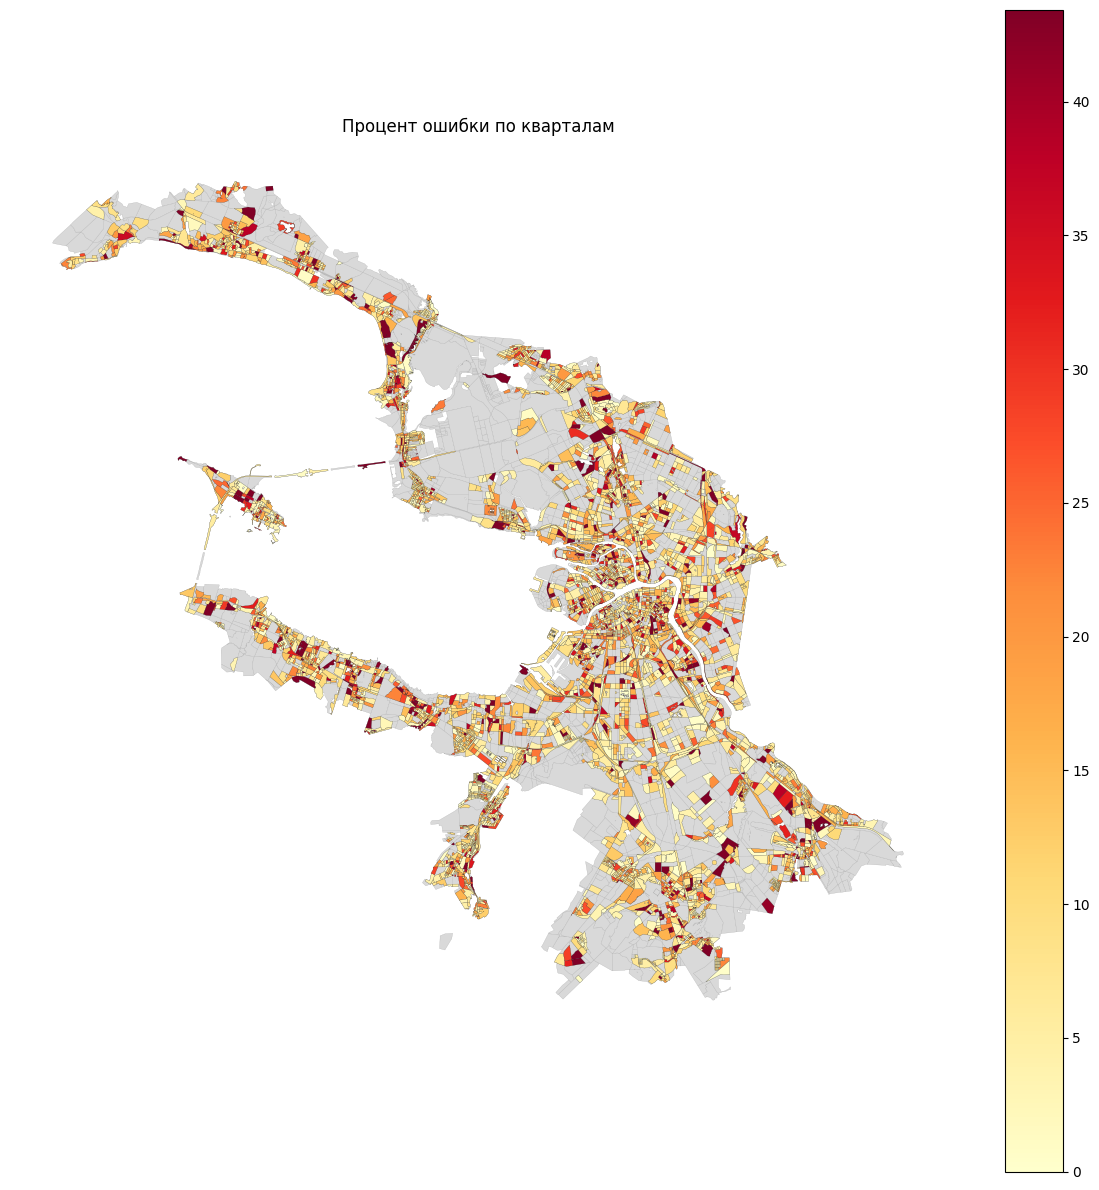

In [43]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Слой с ошибками
gdf_err = gpd.GeoDataFrame(result_df.copy(), geometry="geometry", crs=blocks_clean.crs)

# Фоновый слой всех кварталов
gdf_blocks = gpd.GeoDataFrame(blocks.copy(), geometry="geometry", crs=blocks_clean.crs).to_crs(gdf_err.crs)

vmax = np.nanpercentile(gdf_err["error_pct"], 95)

fig, ax = plt.subplots(figsize=(12, 12))

# 1) Низ: все кварталы серым
gdf_blocks.plot(
    ax=ax,
    color="#d9d9d9",
    edgecolor="#b0b0b0",
    linewidth=0.2,
    alpha=1.0,
    zorder=1,
)

# 2) Верх: процент ошибки
gdf_err.plot(
    ax=ax,
    column="error_pct",
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.1,
    vmin=0,
    vmax=vmax,
    legend=True,
    zorder=2,
)

ax.set_title("Процент ошибки по кварталам")
ax.set_axis_off()
plt.tight_layout()
plt.show()


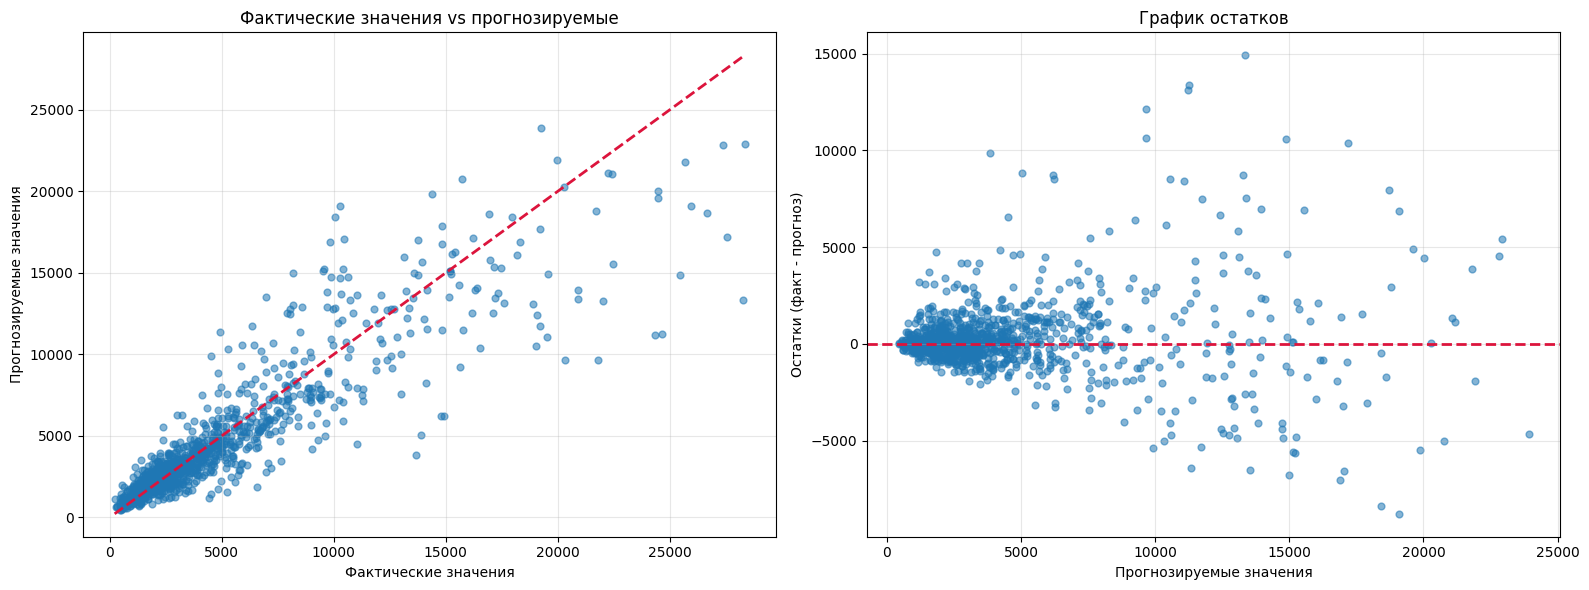

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plot_mask = np.isfinite(y_test_true) & np.isfinite(y_test_pred)
y_true_plot = y_test_true[plot_mask]
y_pred_plot = y_test_pred[plot_mask]
residuals = y_true_plot - y_pred_plot

min_val = min(y_true_plot.min(), y_pred_plot.min())
max_val = max(y_true_plot.max(), y_pred_plot.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Разброс фактических значений по сравнению с прогнозируемыми
axes[0].scatter(y_true_plot, y_pred_plot, alpha=0.55, s=24)
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    color="crimson",
    linestyle="--",
    linewidth=2,
)
axes[0].set_title("Фактические значения vs прогнозируемые")
axes[0].set_xlabel("Фактические значения")
axes[0].set_ylabel("Прогнозируемые значения")
axes[0].grid(alpha=0.3)

# 2. График остатков
axes[1].scatter(y_pred_plot, residuals, alpha=0.55, s=24)
axes[1].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("График остатков")
axes[1].set_xlabel("Прогнозируемые значения")
axes[1].set_ylabel("Остатки (факт - прогноз)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [18]:
import re
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Разбиваем фичи на base / lag-группы по радиусам
lag_groups = {r: [] for r in radius_list}
other_lag_feats = []
base_feats = []

for f in feats:
    matched = False
    for r in radius_list:
        if f.startswith(f"lag{r}_"):
            lag_groups[r].append(f)
            matched = True
            break

    if matched:
        continue

    if f.startswith("lag"):
        other_lag_feats.append(f)
    else:
        base_feats.append(f)

print("Base feats:", len(base_feats))
for r in radius_list:
    print(f"Lag feats radius {r}: {len(lag_groups[r])}")
print("Other lag feats:", len(other_lag_feats))



# 2) Универсальная функция оценки
def evaluate_feature_set(feature_set, name):
    feature_set = list(dict.fromkeys(feature_set))
    feature_set = [f for f in feature_set if f in df_train.columns and f in df_test.columns]
    cat_subset = [c for c in cat_features if c in feature_set]

    train_pool = Pool(
        df_train[feature_set],
        label=df_train[target_col],
        cat_features=cat_subset,
        feature_names=feature_set,
    )
    test_pool = Pool(
        df_test[feature_set],
        label=df_test[target_col],
        cat_features=cat_subset,
        feature_names=feature_set,
    )

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=5000,
        od_type="Iter",
        od_wait=300,
        random_seed=seed,
        verbose=False,
    )

    model.fit(
        train_pool,
        eval_set=test_pool,
        early_stopping_rounds=300,
        use_best_model=True,
        verbose=False,
    )

    y_train_pred_raw = np.asarray(model.predict(df_train[feature_set])).reshape(-1)
    y_test_pred_raw = np.asarray(model.predict(df_test[feature_set])).reshape(-1)

    y_train_true_raw = df_train[target_col].to_numpy()
    y_test_true_raw = df_test[target_col].to_numpy()

    y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
    y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

    y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
    y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

    return {
        "set_name": name,
        "n_features": len(feature_set),
        "best_iteration": model.get_best_iteration() + 1 if model.get_best_iteration() is not None else None,
        "train_mape": mape(y_train_true, y_train_pred),
        "train_wape": wape(y_train_true, y_train_pred),
        "train_mae": mean_absolute_error(y_train_true, y_train_pred),
        "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "train_r2": r2_score(y_train_true, y_train_pred),
        "test_mape": mape(y_test_true, y_test_pred),
        "test_wape": wape(y_test_true, y_test_pred),
        "test_mae": mean_absolute_error(y_test_true, y_test_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
        "test_r2": r2_score(y_test_true, y_test_pred),
        "features": feature_set,
        "model": model,
    }

# 3) Наборы для ablation
candidate_sets = {
    "base_only": base_feats,
}

for r in radius_list:
    candidate_sets[f"base_plus_r{r}"] = base_feats + lag_groups[r]

cumulative = []
for r in radius_list:
    cumulative = cumulative + lag_groups[r]
    candidate_sets[f"base_plus_to_r{r}"] = base_feats + cumulative

if len(other_lag_feats) > 0:
    candidate_sets["base_plus_other_lags"] = base_feats + other_lag_feats
    candidate_sets["all_features"] = base_feats + cumulative + other_lag_feats
else:
    candidate_sets["all_features"] = base_feats + cumulative

# 4) Прогон
ablation_results = []
ablation_models = {}

for name, feature_set in candidate_sets.items():
    res = evaluate_feature_set(feature_set, name)
    ablation_models[name] = res["model"]
    ablation_results.append({k: v for k, v in res.items() if k not in ["features", "model"]})

ablation_df = (
    pd.DataFrame(ablation_results)
    .sort_values(["test_mae", "test_wape", "test_rmse"], ascending=True)
    .reset_index(drop=True)
)

display(ablation_df)

best_ablation_name = ablation_df.iloc[0]["set_name"]
print("Best ablation set:", best_ablation_name)


Base feats: 31
Lag feats radius 300: 24
Lag feats radius 500: 24
Lag feats radius 1000: 24
Lag feats radius 2000: 24
Lag feats radius 3000: 24
Other lag feats: 0


,set_name,n_features,best_iteration,train_mape,train_wape,train_mae,train_rmse,train_r2,test_mape,test_wape,test_mae,test_rmse,test_r2
0,base_plus_r3000,55,3064,0.143036,0.155985,833.293703,1955.845795,0.887790,0.254290,0.240019,1214.888618,2291.042898,0.812424
1,base_plus_r2000,55,5000,0.122248,0.138919,742.126004,1822.332177,0.902586,0.263659,0.242339,1226.633798,2335.688255,0.805042
2,base_plus_r1000,55,3799,0.137107,0.154657,826.198449,1980.375161,0.884957,0.259200,0.244032,1235.200726,2376.988867,0.798086
3,base_plus_to_r3000,151,4292,0.112699,0.135660,724.716139,1869.832480,0.897442,0.258760,0.245918,1244.746909,2385.800787,0.796587
4,all_features,151,4292,0.112699,0.135660,724.716139,1869.832480,0.897442,0.258760,0.245918,1244.746909,2385.800787,0.796587
5,base_plus_to_r2000,127,3710,0.121274,0.145940,779.631781,1989.483861,0.883897,0.262769,0.250733,1269.118085,2425.870888,0.789696
6,base_plus_r500,55,3191,0.150849,0.161202,861.166108,2027.775987,0.879384,0.267137,0.253968,1285.495060,2487.739178,0.778833
7,base_plus_to_r1000,103,3381,0.133091,0.152077,812.418577,2007.252392,0.881813,0.270164,0.254981,1290.621454,2486.757741,0.779007
8,base_only,31,3329,0.170381,0.171410,915.697446,2049.930673,0.876734,0.276476,0.259406,1313.019876,2468.528636,0.782235
9,base_plus_to_r500,79,2462,0.160622,0.171149,914.303402,2144.788783,0.865062,0.276073,0.263414,1333.306696,2588.882735,0.760483


Best ablation set: base_plus_r3000


In [19]:
selected_features = candidate_sets["base_plus_r3000"]


In [93]:
# === Simple train/test training with selected features ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from catboost import CatBoostRegressor, Pool
from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "land_value_per_sqm"
radius_list = [300, 500, 1000, 2000, 3000]
test_size = 0.1
seed = 42
use_services = False

# Сюда можно передать отобранные фичи, например:
# selected_features = top_60_features
selected_features = None

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    "land_value_class_soft_expected",
    "district_name",
}

cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи
data_df = blocks_clean.copy()

for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [
    c for c in feature_cols
    if c not in cat_features and c != target_col and c in data_df.columns
]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(
    [c for c in feature_cols if c in data_lag.columns] + cat_features
))
all_feats = feature_names(data_lag, base_cols_for_model, target_col)

selected_features = candidate_sets["base_plus_r3000"]

# 4) Выбор фичей для обучения
if selected_features is None:
    feats = all_feats
else:
    feats = [f for f in selected_features if f in all_feats]
    if len(feats) == 0:
        raise ValueError("selected_features is empty after filtering by available model features")

cat_features_model = [c for c in cat_features if c in feats]

print(f"Total available features: {len(all_feats)}")
print(f"Selected features for training: {len(feats)}")

# 5) Train/test split
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(
    df_train[feats],
    label=df_train[target_col],
    cat_features=cat_features_model,
    feature_names=feats,
)
test_pool = Pool(
    df_test[feats],
    label=df_test[target_col],
    cat_features=cat_features_model,
    feature_names=feats,
)

# 6) Обучение
model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=20000,
    od_type="Iter",
    od_wait=2000,
    random_seed=seed,
    verbose=200,
)

model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=600,
    use_best_model=True,
)

# 7) Метрики на train/test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model.predict(df_train[feats])).reshape(-1)
y_train_true_raw = df_train[target_col].to_numpy()

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")


Total available features: 151
Selected features for training: 55
0:	learn: 3050.7296092	test: 3043.9532527	best: 3043.9532527 (0)	total: 6.18ms	remaining: 2m 3s
200:	learn: 1358.1073545	test: 1466.9654128	best: 1466.9654128 (200)	total: 734ms	remaining: 1m 12s
400:	learn: 1199.9915316	test: 1395.8388041	best: 1395.8388041 (400)	total: 1.38s	remaining: 1m 7s
600:	learn: 1100.1193614	test: 1359.6556439	best: 1359.6556439 (600)	total: 2.04s	remaining: 1m 5s
800:	learn: 1025.2902230	test: 1339.1030518	best: 1339.1030518 (800)	total: 2.75s	remaining: 1m 5s
1000:	learn: 969.5750152	test: 1328.7600835	best: 1328.7600835 (1000)	total: 3.41s	remaining: 1m 4s
1200:	learn: 927.4176367	test: 1320.9896322	best: 1320.8643385 (1198)	total: 4.06s	remaining: 1m 3s
1400:	learn: 897.7207254	test: 1315.4644983	best: 1315.4644983 (1400)	total: 4.74s	remaining: 1m 2s
1600:	learn: 865.6066783	test: 1309.5474533	best: 1309.0247450 (1589)	total: 5.43s	remaining: 1m 2s
1800:	learn: 841.0553487	test: 1306.867879

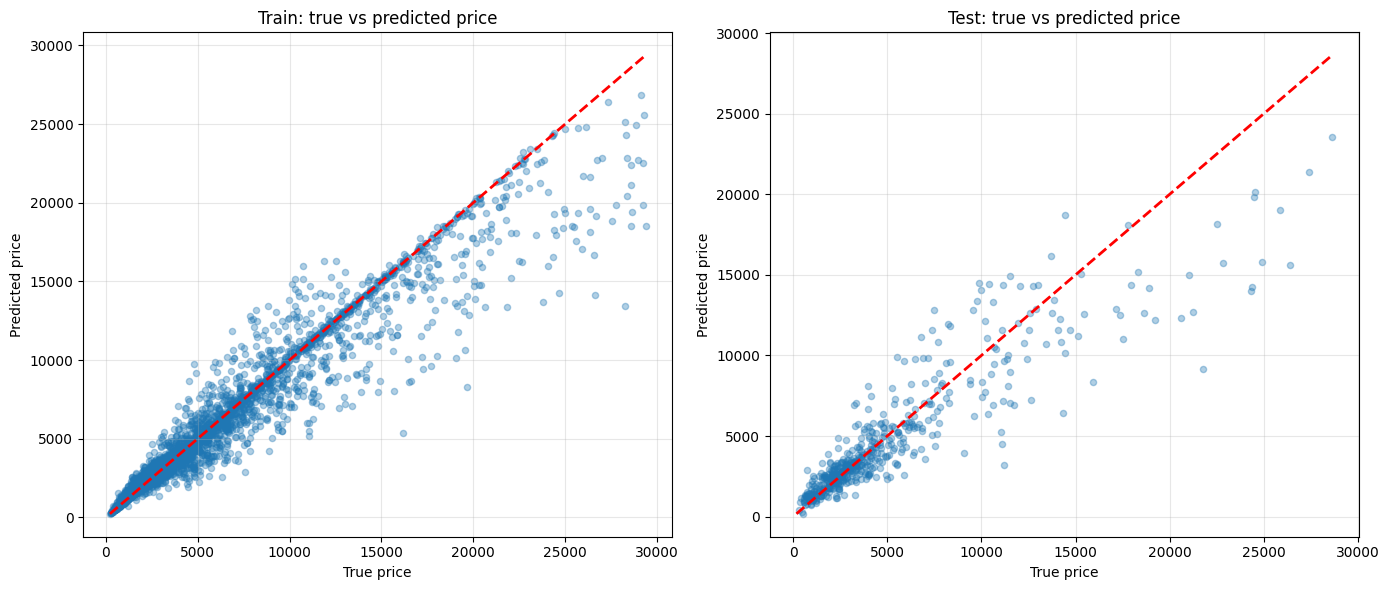

In [95]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

# Train
axes[0].scatter(y_train_true, y_train_pred, alpha=0.35, s=20)
mn = min(y_train_true.min(), y_train_pred.min())
mx = max(y_train_true.max(), y_train_pred.max())
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=2)
axes[0].set_title("Train: true vs predicted price")
axes[0].set_xlabel("True price")
axes[0].set_ylabel("Predicted price")
axes[0].grid(alpha=0.3)

# Test
axes[1].scatter(y_test_true, y_test_pred, alpha=0.35, s=20)
mn = min(y_test_true.min(), y_test_pred.min())
mx = max(y_test_true.max(), y_test_pred.max())
axes[1].plot([mn, mx], [mn, mx], "r--", linewidth=2)
axes[1].set_title("Test: true vs predicted price")
axes[1].set_xlabel("True price")
axes[1].set_ylabel("Predicted price")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Основное обучение

In [31]:
from urbanomy.methods.land_value_modeling.training_utils import TrainingConfig, run_training
import logging

# Флаг: учить с сервисами (count_*) или без
use_services = False   # False -> исключаем все count_* фичи

target_col = "land_value_per_sqm"
radius_list = [300, 500, 1000, 2000, 3000]

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    'land_value_class_soft_expected',
    'district_name',
}

def is_service_col(col: str) -> bool:
    # сервисы у тебя обычно в формате count_...
    # если есть другие варианты (например Count_ / COUNT_), делаем lower()
    c = col.lower()
    return c.startswith("count_")

# формируем feature_cols с учетом флага
feature_cols = []
for c in blocks.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

cat_features = ["land_use", "morphotype", 'land_value_class_pred',]

cfg = TrainingConfig(
    feature_cols=feature_cols,
    cat_features=cat_features,
    radius_list=radius_list,
    target_col=target_col,
    group_col="district_name",
    loss_function="MAE",
    eval_metric="MAE",
    hpo_iter=1,
    param_grid={
        "depth": [6],
        "learning_rate": [0.03],
        "l2_leaf_reg": [3],
        "random_strength": [1.0],
        "bagging_temperature": [1.0],
    },
    # n_clusters=20,
    inner_splits=5,
    outer_splits=5,
    iterations=20000,
    od_wait=2000,
    seed=42,
)

model, metrics = run_training(
    blocks_clean,
    cfg,
    log_path=f"catboost_info/training_{'with_services' if use_services else 'no_services'}.log",
    console_level=logging.WARNING,
)

print("use_services =", use_services)
print(metrics)
 

OuterCV:   0%|          | 0/5 [00:00<?, ?it/s]

Trials:   0%|          | 0/1 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

0:	learn: 3016.3789910	total: 6.38ms	remaining: 4.39s
200:	learn: 1401.3352569	total: 1.32s	remaining: 3.19s
400:	learn: 1262.2457794	total: 2.62s	remaining: 1.88s
600:	learn: 1165.0031875	total: 3.92s	remaining: 567ms
687:	learn: 1129.9548169	total: 4.51s	remaining: 0us
2026-03-03 15:24:54,347 | WARNING | Train metrics:
MAPE: 0.223430 (22.34%)
WAPE: 0.222336 (22.23%)
MAE:  1131.313523
RMSE: 2183.696693
R2:   0.798186

Test metrics:
MAPE: 0.415931 (41.59%)
WAPE: 0.340791 (34.08%)
MAE:  1731.242564
RMSE: 2802.473330
R2:   0.599178
use_services = False
{'r2': 0.599177956509114, 'r2_std': 0.07933672330013218, 'mae': 1731.2425643670645, 'mae_std': 426.6776790406584, 'rmse': 2802.473330024835, 'rmse_std': 674.6470388986884, 'nrmse': 0.09748807358864289, 'nrmse_std': 0.023170303937225956, 'mean_error': -385.7108184707428, 'mean_error_std': 600.866227778509, 'mpe': 16.7656061984216, 'mpe_std': 15.537122924208472, 'mape': 41.59309348327169, 'mape_std': 5.970262670424363, 'wape': 34.07908873928

In [32]:
district_counts = (
    blocks_clean
    .assign(district_name=blocks_clean["district_name"].astype("string").fillna("missing"))
    .groupby("district_name", dropna=False)
    .size()
    .reset_index(name="n_blocks")
    .sort_values("n_blocks", ascending=False)
)

display(district_counts)


,district_name,n_blocks
9,Курортный район,733
7,Красносельский район,656
15,Пушкинский район,627
14,Приморский район,484
13,Петродворцовый район,452
2,Выборгский район,382
5,Колпинский район,263
17,Центральный район,226
11,Невский район,214
6,Красногвардейский район,214


In [33]:
from sklearn.model_selection import GroupKFold
import pandas as pd

groups = pd.factorize(blocks_clean["district_name"].astype("string").fillna("missing_group"))[0]
gkf = GroupKFold(n_splits=cfg.outer_splits)

for i, (train_idx, test_idx) in enumerate(
    gkf.split(blocks_clean, blocks_clean[cfg.target_col], groups), 1
):
    print(f"Fold {i}")
    print(f"  train rows: {len(train_idx)}")
    print(f"  test rows:  {len(test_idx)}")
    print(f"  train districts: {len(set(groups[train_idx]))}")
    print(f"  test districts:  {len(set(groups[test_idx]))}")


Fold 1
  train rows: 4382
  test rows:  1076
  train districts: 15
  test districts:  3
Fold 2
  train rows: 4321
  test rows:  1137
  train districts: 14
  test districts:  4
Fold 3
  train rows: 4409
  test rows:  1049
  train districts: 15
  test districts:  3
Fold 4
  train rows: 4395
  test rows:  1063
  train districts: 14
  test districts:  4
Fold 5
  train rows: 4325
  test rows:  1133
  train districts: 14
  test districts:  4


In [20]:
# === SHAP: beeswarm + bar для текущей модели ===
import shap

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
)

target_col = cfg.target_col

numeric_feats = [
    c for c in cfg.feature_cols
    if c not in cfg.cat_features and c != target_col and c in blocks_clean.columns
]

work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cfg.cat_features)

weights_shap = build_radii_weights(work_df, cfg.radius_list)
data_lag_shap = add_lags_full_df(work_df, weights=weights_shap, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + list(cfg.cat_features)))
feats = feature_names(data_lag_shap, base_cols_for_model, target_col)

X_shap = data_lag_shap[feats]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# 1) Beeswarm
shap.summary_plot(shap_values, X_shap, feature_names=feats, show=True)



NameError: name 'cfg' is not defined

In [32]:
# === Inference + метрики для текущей модели ===
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
    rmse,
)

target_col = cfg.target_col

# 1) Восстанавливаем тот же набор числовых фич, что использовался при обучении
numeric_feats = [
    c for c in cfg.feature_cols
    if c not in cfg.cat_features and c != target_col and c in blocks_clean.columns
]

# 2) Готовим данные и считаем лаги так же, как в run_training
work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cfg.cat_features)

weights_inf = build_radii_weights(work_df, cfg.radius_list)
data_lag_inf = add_lags_full_df(work_df, weights=weights_inf, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + list(cfg.cat_features)))
feats = feature_names(data_lag_inf, base_cols_for_model, target_col)

# 3) Проверка фичей
missing_feats = [c for c in feats if c not in data_lag_inf.columns]
if missing_feats:
    raise ValueError(
        f"Не хватает фичей для модели ({len(missing_feats)}): "
        f"{missing_feats[:20]}{' ...' if len(missing_feats) > 20 else ''}"
    )

# 4) Предсказание
y_pred_raw = np.asarray(model.predict(data_lag_inf[feats])).reshape(-1)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

out_df = data_lag_inf.copy()
out_df["pred_raw"] = y_pred_raw
out_df[f"{target_col}_pred"] = y_pred

# 5) Метрики
if target_col in out_df.columns:
    y_true_raw = out_df[target_col].to_numpy()
    y_true = to_original_scale(y_true_raw, target_col=target_col)

    out_df[f"{target_col}_true"] = y_true

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > 0)

    out_df["error_pct"] = np.nan
    out_df.loc[mask, "error_pct"] = (
        np.abs(y_pred[mask] - y_true[mask]) / np.abs(y_true[mask]) * 100.0
    )

    mape_val = mape(y_true[mask], y_pred[mask])
    wape_val = wape(y_true[mask], y_pred[mask])
    mae_val = mean_absolute_error(y_true[mask], y_pred[mask])
    rmse_val = rmse(y_true[mask], y_pred[mask])
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"Rows used in metrics: {mask.sum()} / {len(mask)}")
    print(f"MAPE: {mape_val:.6f} ({mape_val*100:.2f}%)")
    print(f"WAPE: {wape_val:.6f} ({wape_val*100:.2f}%)")
    print(f"MAE:  {mae_val:.6f}")
    print(f"RMSE: {rmse_val:.6f}")
    print(f"R2:   {r2_val:.6f}")

    display(out_df[[target_col, f"{target_col}_pred", "error_pct"]].head(20))

    out_df_over_10 = out_df[out_df["error_pct"] > 10].copy()
else:
    print(f"Column '{target_col}' not found -> predictions only.")
    display(out_df[[f"{target_col}_pred"]].head(20))


NameError: name 'cfg' is not defined

In [57]:
stats_by_landuse = (
    out_df
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct
land_use,,,,,
AGRICULTURE,41,34.458658,23.250193,64.704431,194.232539
RECREATION,607,27.732788,17.935663,63.069751,223.621437
SPECIAL,67,24.079187,14.247690,53.002193,135.209279
TRANSPORT,530,22.662225,17.480273,46.174727,148.134025
INDUSTRIAL,337,19.494689,13.694827,42.603755,150.510385
BUSINESS,230,18.463603,10.865267,42.663828,104.238610
RESIDENTIAL,3309,15.337882,10.635261,33.137361,292.330822


In [58]:
out_df_over_100 = out_df[out_df["error_pct"] > 100]
out_df_100 = out_df[out_df["error_pct"] <= 100]

stats_by_landuse = (
    out_df_over_100
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
)

stats_by_landuse["share_of_all_plots_pct"] = (
    stats_by_landuse["n"] / len(out_df) * 100
)

stats_by_landuse = stats_by_landuse.sort_values("mean_error_pct", ascending=False)

display(stats_by_landuse)


,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct,share_of_all_plots_pct
land_use,,,,,,
AGRICULTURE,2,161.511298,161.511298,187.688290,194.232539,0.039055
RESIDENTIAL,10,149.000752,127.237814,219.516791,292.330822,0.195274
RECREATION,27,139.003946,134.163691,175.784204,223.621437,0.527241
INDUSTRIAL,2,135.571146,135.571146,147.522537,150.510385,0.039055
SPECIAL,2,124.132173,124.132173,132.993858,135.209279,0.039055
TRANSPORT,6,117.054818,106.133160,140.538145,148.134025,0.117165
BUSINESS,1,104.238610,104.238610,104.238610,104.238610,0.019527


In [45]:
# === Conformal interval по land_use ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

alpha = 0.10  # 90% PI
group_col = "land_use"
true_col = "land_value_per_sqm_true"
pred_col = "land_value_per_sqm_pred"

# 1) валидные строки
valid_mask = (
    np.isfinite(out_df[true_col].to_numpy()) &
    np.isfinite(out_df[pred_col].to_numpy()) &
    out_df[group_col].notna()
)
df_valid = out_df.loc[valid_mask].copy()

# 2) calibration / evaluation
idx_cal, idx_eval = train_test_split(
    df_valid.index, test_size=0.5, random_state=42, shuffle=True
)
cal_df = df_valid.loc[idx_cal].copy()
eval_df = df_valid.loc[idx_eval].copy()

# 3) глобальный q_hat (fallback)
abs_err_cal_all = np.abs(cal_df[pred_col] - cal_df[true_col]).to_numpy()
n_all = len(abs_err_cal_all)
k_all = int(np.ceil((n_all + 1) * (1 - alpha)))
k_all = min(max(k_all, 1), n_all)
q_hat_global = np.partition(abs_err_cal_all, k_all - 1)[k_all - 1]

# 4) q_hat по группам land_use
min_cal_size = 30  # если в группе мало точек, используем глобальный q_hat
qhat_by_group = {}

for g, gdf in cal_df.groupby(group_col):
    abs_err = np.abs(gdf[pred_col] - gdf[true_col]).to_numpy()
    n = len(abs_err)
    if n < min_cal_size:
        qhat_by_group[g] = q_hat_global
        continue
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    qhat_by_group[g] = np.partition(abs_err, k - 1)[k - 1]

# 5) строим интервалы
q_series = out_df[group_col].map(qhat_by_group).fillna(q_hat_global)
out_df["q_hat_land_use"] = q_series

out_df["pi_lower"] = (out_df[pred_col] - out_df["q_hat_land_use"]).clip(lower=0)
out_df["pi_upper"] = out_df[pred_col] + out_df["q_hat_land_use"]

# 6) оценка покрытия на eval
eval_tmp = out_df.loc[idx_eval].copy()
covered_eval = (eval_tmp[true_col] >= eval_tmp["pi_lower"]) & (eval_tmp[true_col] <= eval_tmp["pi_upper"])

coverage_eval_total = covered_eval.mean() * 100
avg_width_eval_total = (eval_tmp["pi_upper"] - eval_tmp["pi_lower"]).mean()

print(f"Target coverage: {(1-alpha)*100:.1f}%")
print(f"Empirical coverage (eval, total): {coverage_eval_total:.2f}%")
print(f"Average interval width (eval, total): {avg_width_eval_total:.2f}")

# покрытие по land_use
coverage_by_landuse = (
    eval_tmp.assign(covered=covered_eval)
    .groupby(group_col)
    .agg(
        n=("covered", "size"),
        coverage_pct=("covered", lambda s: s.mean() * 100),
        avg_width=("pi_upper", lambda s: (s - eval_tmp.loc[s.index, "pi_lower"]).mean()),
        q_hat=("q_hat_land_use", "mean"),
    )
    .sort_values("coverage_pct")
)

display(coverage_by_landuse)
display(out_df[[group_col, true_col, pred_col, "pi_lower", "pi_upper", "q_hat_land_use"]].head(20))


NameError: name 'out_df' is not defined

In [25]:
# model_path = f"catboost_land_value_{'with_services' if use_services else 'no_services'}.cbm"
# model.save_model(model_path)
# print(model_path)

